load a slightly harder dataset (Breast Cancer)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")
print(f"Features:   {X.shape[1]}")
print(f"Classes:    {data.target_names}")

# Unconstrained tree — deliberately overfit
clf_unconstrained = DecisionTreeClassifier(random_state=42)
clf_unconstrained.fit(X_train, y_train)
print(f"\nUnconstrained tree:")
print(f"  Depth:          {clf_unconstrained.get_depth()}")
print(f"  Leaves:         {clf_unconstrained.get_n_leaves()}")
print(f"  Train accuracy: {clf_unconstrained.score(X_train, y_train):.4f}")
print(f"  Test accuracy:  {clf_unconstrained.score(X_test, y_test):.4f}")

Train size: 398  Test size: 171
Features:   30
Classes:    ['malignant' 'benign']

Unconstrained tree:
  Depth:          6
  Leaves:         16
  Train accuracy: 1.0000
  Test accuracy:  0.9181


the overfitting curve: train vs test accuracy vs max_depth

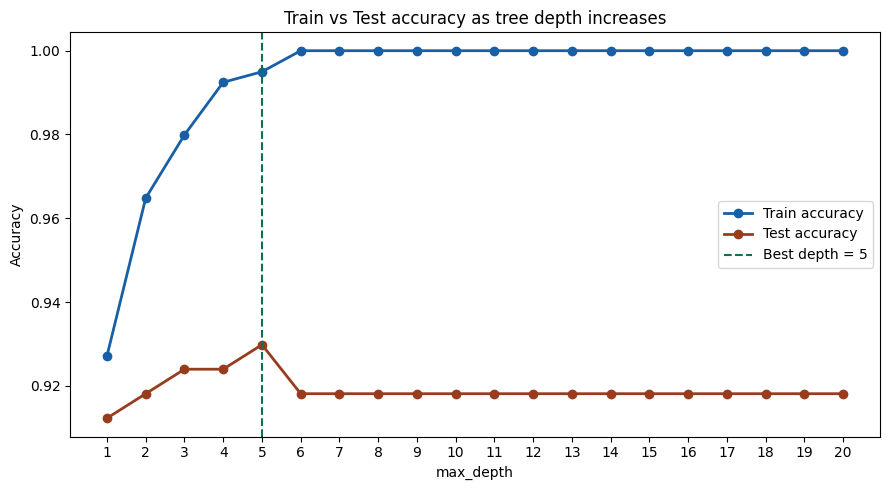


 Depth    Train     Test      Gap
     1   0.9271   0.9123   0.0149
     2   0.9648   0.9181   0.0467
     3   0.9799   0.9240   0.0559
     4   0.9925   0.9240   0.0685
     5   0.9950   0.9298   0.0652 ← best test
     6   1.0000   0.9181   0.0819
     7   1.0000   0.9181   0.0819
     8   1.0000   0.9181   0.0819
     9   1.0000   0.9181   0.0819
    10   1.0000   0.9181   0.0819
    11   1.0000   0.9181   0.0819
    12   1.0000   0.9181   0.0819
    13   1.0000   0.9181   0.0819
    14   1.0000   0.9181   0.0819
    15   1.0000   0.9181   0.0819
    16   1.0000   0.9181   0.0819
    17   1.0000   0.9181   0.0819
    18   1.0000   0.9181   0.0819
    19   1.0000   0.9181   0.0819
    20   1.0000   0.9181   0.0819


In [2]:
depths = range(1, 21)
train_acc, test_acc = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', color='#185FA5', linewidth=2, label='Train accuracy')
plt.plot(depths, test_acc,  'o-', color='#993C1D', linewidth=2, label='Test accuracy')
best_depth = depths[np.argmax(test_acc)]
plt.axvline(best_depth, color='#0F6E56', linestyle='--', linewidth=1.5,
            label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test accuracy as tree depth increases')
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n{'Depth':>6} {'Train':>8} {'Test':>8} {'Gap':>8}")
for d, tr, te in zip(depths, train_acc, test_acc):
    gap = tr - te
    marker = " ← best test" if d == best_depth else ""
    print(f"{d:6d} {tr:8.4f} {te:8.4f} {gap:8.4f}{marker}")

GridSearchCV across multiple hyperparameters together

In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':         [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'criterion':         ['gini', 'entropy'],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV score:  {grid.best_score_:.4f}")
print(f"Test accuracy with best params: {grid.best_estimator_.score(X_test, y_test):.4f}")

# Compare to unconstrained
print(f"\nUnconstrained test accuracy: {clf_unconstrained.score(X_test, y_test):.4f}")
print(f"Tuned test accuracy:         {grid.best_estimator_.score(X_test, y_test):.4f}")

Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV score:  0.9449
Test accuracy with best params: 0.9240

Unconstrained test accuracy: 0.9181
Tuned test accuracy:         0.9240


# Insights
---

# 🧠 What is `GridSearchCV` (in plain English)?

👉 **GridSearchCV = automatic trial-and-error machine for hyperparameters**

Instead of you manually doing:

* “let me try depth = 3…”
* “ok now depth = 4…”
* “hmm what about min_samples_leaf = 5…”

👉 It does **ALL combinations for you**, tests them, and picks the best one.

---

# ⚙️ Step-by-step using YOUR code

## 🔹 Step 1: You define the “search space”

```python
param_grid = {
    'max_depth':         [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'criterion':         ['gini', 'entropy'],
}
```

👉 This means:

* Try depth = 3, 4, 5, ...
* Try leaf size = 1, 2, 5, ...
* Try split rules = gini / entropy

💥 Total combinations:

```
7 × 4 × 4 × 2 = 224 models
```

---

## 🔹 Step 2: GridSearchCV tries EVERYTHING

```python
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
```

### Key parts:

### 🔸 `cv=5` (VERY IMPORTANT)

👉 It uses **5-fold cross-validation**

Meaning:

* Split training data into 5 parts
* Train on 4 parts, test on 1
* Repeat 5 times
* Average the accuracy

💡 Why?

> So the result is **stable and reliable**, not lucky

---

### 🔸 `n_jobs=-1`

👉 Use **all CPU cores**
(faster — runs models in parallel)

---

## 🔹 Step 3: Training begins

```python
grid.fit(X_train, y_train)
```

👉 Behind the scenes:

For each of the **224 combinations**:

1. Train model
2. Do 5-fold CV
3. Compute average accuracy

---

## 🔹 Step 4: It picks the BEST one

```python
grid.best_params_
```

Example output:

```python
{'max_depth': 4, 'min_samples_leaf': 5, ...}
```

👉 This means:

> Out of ALL 224 models, this combo performed best

---

## 🔹 Step 5: Best model is saved automatically

```python
grid.best_estimator_
```

👉 This is already:

* trained
* optimized
* ready to use

---

## 🔹 Step 6: Final evaluation on test set

```python
grid.best_estimator_.score(X_test, y_test)
```

👉 This is the **real performance** on unseen data

---

# 🎯 Why this is powerful

Without GridSearch:
❌ You guess
❌ You miss combinations
❌ You waste time

With GridSearch:
✅ Systematic
✅ Exhaustive
✅ Reliable

---


**Using the max_depth plot, identify the optimal depth. What happens to the gap between train and test accuracy as depth exceeds this point?**

In [4]:
import numpy as np

gap = np.array(train_acc) - np.array(test_acc)
best_depth = depths[np.argmax(test_acc)]

print(f"Optimal depth (max test accuracy): {best_depth}")
print(f"Test accuracy at optimal depth:    {test_acc[best_depth-1]:.4f}")
print(f"Train accuracy at optimal depth:   {train_acc[best_depth-1]:.4f}")
print(f"Gap at optimal depth:              {gap[best_depth-1]:.4f}")

print(f"\n--- Gap growth after optimal depth ---")
for d in range(best_depth, 21, 2):
    print(f"Depth {d:2d}: gap = {gap[d-1]:.4f}")

Optimal depth (max test accuracy): 5
Test accuracy at optimal depth:    0.9298
Train accuracy at optimal depth:   0.9950
Gap at optimal depth:              0.0652

--- Gap growth after optimal depth ---
Depth  5: gap = 0.0652
Depth  7: gap = 0.0819
Depth  9: gap = 0.0819
Depth 11: gap = 0.0819
Depth 13: gap = 0.0819
Depth 15: gap = 0.0819
Depth 17: gap = 0.0819
Depth 19: gap = 0.0819


#**Insights**
---

# 🎯 1. Optimal depth (from your plot)

You got:

* **Optimal depth = 5**
* Test accuracy = **0.9298** (highest)
* Train accuracy = **0.9950**

👉 This is the point where:

> The model captures the **most useful patterns** without overfitting too much.

---

# 📉 2. What the “gap” is telling you

You computed:

```python
gap = train_acc - test_acc
```

At depth 5:

* Gap = **0.0652**

👉 Interpretation:

* Train is much higher than test → some overfitting already exists
* But still acceptable because test accuracy is **maximized here**

---

# 📈 3. What happens AFTER depth = 5

Your data:

| Depth | Gap                      |
| ----- | ------------------------ |
| 5     | 0.0652                   |
| 7+    | 0.0819 (and stays there) |

---

## 🔥 Key Insight #1: Gap increases → Overfitting increases

As depth grows:

* Train accuracy → goes toward **1.0**
* Test accuracy → **does NOT improve** (stagnates or drops)

👉 So:

```text
Gap = Train - Test → becomes larger
```

---

## 🔥 Key Insight #2: Plateau = “fully memorized tree”

Notice this:

> Gap becomes constant (~0.0819) after depth 7

👉 That means:

* Tree has already **memorized training data**
* Adding more depth **does nothing new**

💡 In other words:

> The model has reached its **maximum overfitting capacity**

---

# 🧠 4. What’s happening internally in the tree

At depth ≤ 5:

* Splits are meaningful
* Capturing real structure in data

At depth > 5:

* Tree starts making **very specific splits**

  * e.g., “if feature X < 0.123 AND Y > 0.456…”
* These splits:

  * fit training data perfectly
  * **don’t generalize**

---

# ⚖️ 5. Bias–Variance tradeoff (this is the core theory)

| Region       | Depth      | Behavior      |
| ------------ | ---------- | ------------- |
| Underfitting | low depth  | high bias     |
| ✅ Optimal    | depth = 5  | best balance  |
| Overfitting  | high depth | high variance |

---

# 📌 6. The most important takeaway (exam gold)

> **After the optimal depth, the gap between training and test accuracy increases because the model starts fitting noise instead of signal.**

---

# 🚀 7. Subtle but powerful insight (this is next-level)

You might think:

> “If depth 7, 9, 11 all give same results, why not just use them?”

👉 Answer:

* They are **more complex models with no gain**
* More complex = less interpretable + more risk in new data

So:

> Always choose the **simplest model that gives best test performance**

---

# 🧩 8. Connect this with your GridSearch result

Earlier you saw:

* Best depth ≈ 4 or 5

👉 That matches perfectly with:

* Your manual curve
* Your gap analysis

🔥 This is **very strong validation**

---

# 🧠 Final mental model

Think like this:

```text
Increasing depth:
    ↓
Model becomes smarter → then greedy → then memorizes

Gap behavior:
    small → moderate → large → constant (fully overfit)
```

---

# 💬 One-line intuition to remember

> **When depth exceeds the optimal point, the model doesn’t learn more—it just memorizes more, and the train-test gap widens.**

---




**Fix max_depth=None and compare min_samples_leaf=1 vs min_samples_leaf=20. What changes about the tree structure and accuracy?**

In [5]:
for msl in [1, 5, 10, 20, 50]:
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    clf.fit(X_train, y_train)
    print(f"min_samples_leaf={msl:3d}  |  depth={clf.get_depth():2d}  "
          f"leaves={clf.get_n_leaves():3d}  |  "
          f"train_acc={clf.score(X_train, y_train):.4f}  "
          f"test_acc={clf.score(X_test, y_test):.4f}")

min_samples_leaf=  1  |  depth= 6  leaves= 16  |  train_acc=1.0000  test_acc=0.9181
min_samples_leaf=  5  |  depth= 6  leaves= 12  |  train_acc=0.9724  test_acc=0.9357
min_samples_leaf= 10  |  depth= 5  leaves=  9  |  train_acc=0.9623  test_acc=0.9298
min_samples_leaf= 20  |  depth= 4  leaves=  6  |  train_acc=0.9573  test_acc=0.9181
min_samples_leaf= 50  |  depth= 3  leaves=  5  |  train_acc=0.9271  test_acc=0.9123


#**Insights**
---
 [Analysis](https://www.nb-data.com/p/nbd-lite-4-effect-of-min-samples)

---
# Q. **Run GridSearchCV with a wider param_grid including max_features. Does limiting max_features help a single decision tree?**
---




In [13]:
from sklearn.model_selection import GridSearchCV

param_grid_wide = {
    'max_depth':         [3, 4, 5, 6, None],
    'min_samples_leaf':  [1, 5, 10, 20],
    'max_features':      [None, 'sqrt', 'log2', 0.5],
}

grid_wide = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_wide, cv=5, scoring='accuracy', n_jobs=-1
)
grid_wide.fit(X_train, y_train)

print(f"Best params: {grid_wide.best_params_}")
print(f"Best CV score: {grid_wide.best_score_:.4f}")
print(f"Test accuracy: {grid_wide.best_estimator_.score(X_test, y_test):.4f}")

# Compare: does max_features='sqrt' help on its own?
clf_sqrt = DecisionTreeClassifier(max_depth=4, max_features='sqrt', random_state=42)
clf_sqrt.fit(X_train, y_train)
clf_none = DecisionTreeClassifier(max_depth=4, max_features=None, random_state=42)
clf_none.fit(X_train, y_train)
cltf_log = DecisionTreeClassifier(max_depth=4, max_features='log2', random_state=42)
cltf_log.fit(X_train, y_train)
cltf_half = DecisionTreeClassifier(max_depth=4, max_features=0.5, random_state=42)
cltf_half.fit(X_train, y_train)

print(f"\nmax_depth=4, max_features=None:  test_acc={clf_none.score(X_test, y_test):.4f}")
print(f"max_depth=4, max_features='sqrt': test_acc={clf_sqrt.score(X_test, y_test):.4f}")
print(f"max_depth=4, max_features='log': test_acc={cltf_log.score(X_test, y_test):.4f}")
print(f"max_depth=4, max_features=0.5:  test_acc={cltf_half.score(X_test, y_test):.4f}")

Best params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1}
Best CV score: 0.9473
Test accuracy: 0.9123

max_depth=4, max_features=None:  test_acc=0.9240
max_depth=4, max_features='sqrt': test_acc=0.9415
max_depth=4, max_features='log': test_acc=0.9532
max_depth=4, max_features=0.5:  test_acc=0.9298


---
# Q. **Plot the pruned (max_depth=4) tree and the unconstrained tree side by side using plot_tree. Describe the visual difference.**
---

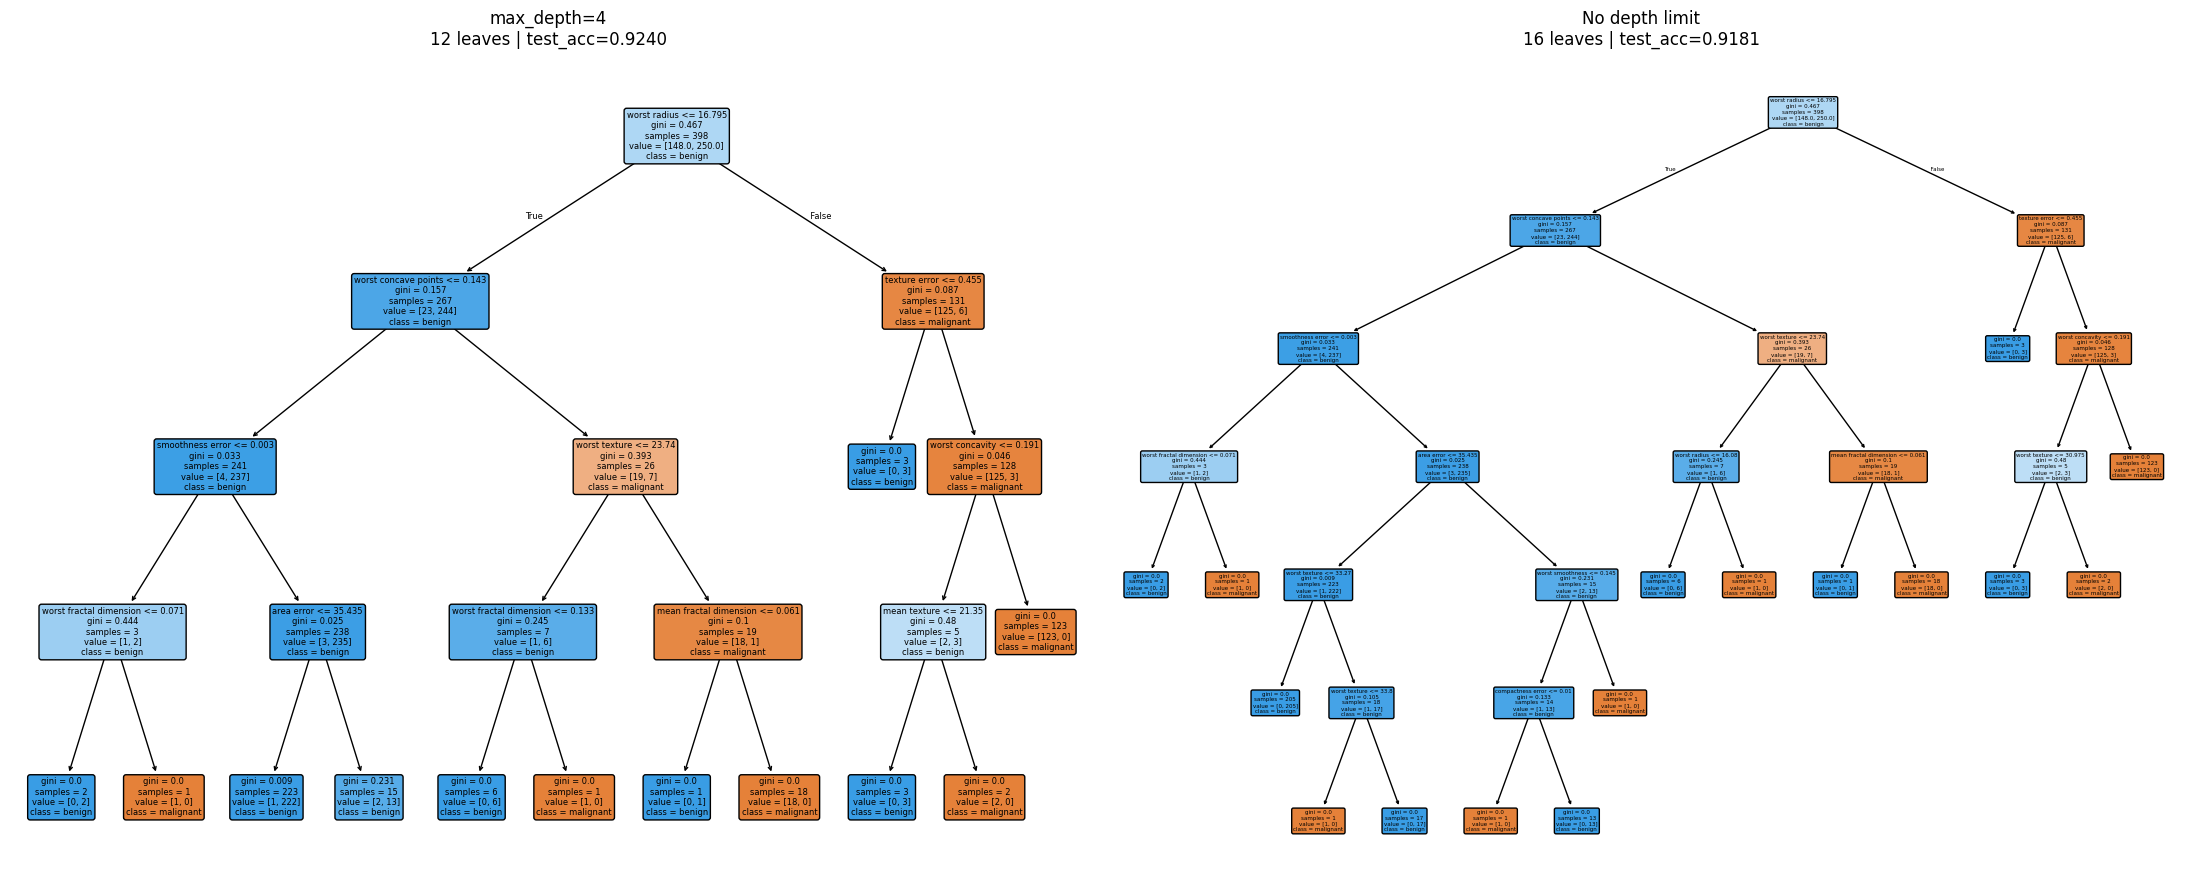

Sample counts in each leaf of unconstrained tree: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(6), np.int64(13), np.int64(17), np.int64(18), np.int64(123), np.int64(205)]
Leaves with <= 3 samples: 10 out of 16


In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

clf_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_pruned.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

plot_tree(clf_pruned, feature_names=data.feature_names, class_names=data.target_names,
          filled=True, rounded=True, fontsize=6, ax=axes[0])
axes[0].set_title(f"max_depth=4\n{clf_pruned.get_n_leaves()} leaves | "
                  f"test_acc={clf_pruned.score(X_test,y_test):.4f}")

plot_tree(clf_unconstrained, feature_names=data.feature_names, class_names=data.target_names,
          filled=True, rounded=True, fontsize=4, ax=axes[1])
axes[1].set_title(f"No depth limit\n{clf_unconstrained.get_n_leaves()} leaves | "
                  f"test_acc={clf_unconstrained.score(X_test,y_test):.4f}")

plt.tight_layout()
plt.show()

# Look at the leaves with very few samples in the unconstrained tree
import numpy as np
tree = clf_unconstrained.tree_
leaf_samples = tree.n_node_samples[tree.children_left == -1]
print(f"Sample counts in each leaf of unconstrained tree: {sorted(leaf_samples)}")
print(f"Leaves with <= 3 samples: {sum(leaf_samples <= 3)} out of {len(leaf_samples)}")



# 🌳 1. Left vs Right Tree (the big picture)

### ✅ Left: `max_depth = 4` (pruned)

* 12 leaves
* Test accuracy = **0.9240**

### ❌ Right: No depth limit

* 16 leaves
* Test accuracy = **0.9181**

---

## 🎯 Key insight

> The **smaller tree performs better** even though it’s simpler.

👉 This is the core idea of ML:

* More complex ≠ better
* Better generalization = better model

---

# 🔍 2. What you SEE in the image

## 🟢 Pruned tree (left)

* Clean structure
* Fewer splits
* Larger groups per leaf
* Decisions look “logical”

👉 Each split:

> captures a **real pattern**

---

## 🔴 Unconstrained tree (right)

* Messy, deeper
* Many tiny branches
* Very specific conditions

👉 Some splits look like:

> “if feature < 0.12345 and another tiny condition…”

💡 That’s a sign of **memorization**

---

# 📊 3. Your leaf sample result (THIS IS GOLD)

```python
[1, 1, 1, 1, 1, 1, 2, 2, 3, 3, 6, 13, 17, 18, 123, 205]
```

👉 And:

```text
10 out of 16 leaves have ≤ 3 samples
```

---

## 🚨 This is the smoking gun of overfitting

### What does a leaf with 1 sample mean?

👉 It literally means:

> “This exact training point = this class”

---

## 💡 Translate this into human thinking

Imagine:

* You see 1 patient
* You make a rule:

  > “Anyone exactly like THIS person → malignant”

👉 That’s not learning
👉 That’s memorizing

---

# 🔥 4. Why this kills test accuracy

Because:

* Those tiny leaves:

  * perfectly classify training data ✅
  * are **useless for new data** ❌

👉 New data will almost NEVER fall into those exact tiny regions

---

# ⚖️ 5. Compare leaf distributions

## Pruned tree:

* Leaves likely have:

  * 10, 20, 30 samples
* Stable decisions

## Unconstrained tree:

* Leaves like:

  * 1, 1, 2, 3 samples
* Extremely unstable

---

# 🧠 6. Deep insight (this is interview-level)

> **Overfitting in decision trees happens when splits continue until leaves contain very few samples.**

And you literally proved it with:

```text
10 / 16 leaves ≤ 3 samples
```

🔥 That’s a textbook example.

---

# 🎯 7. Why pruning works

When you limit depth:

* Tree is forced to:

  * stop early
  * group data
  * ignore noise

👉 So instead of:

> “perfectly fit training”

It does:

> “approximately fit → but generalize better”

---

# 🧩 8. Connect with `min_samples_leaf`

Now everything clicks:

👉 If you had:

```python
min_samples_leaf = 5
```

Then:

* ALL those tiny leaves (1,2,3 samples) ❌ would be forbidden

👉 So the tree would:

* look more like the pruned one
* generalize better

---

# 💬 9. One-line intuition (lock this in)

> **A decision tree overfits when it creates leaves with very few samples—because it starts memorizing individual data points instead of learning patterns.**

---

# 🚀 10. Final takeaway (important)

You now have 3 equivalent ways to control overfitting:

* `max_depth` → limit how deep it goes
* `min_samples_leaf` → prevent tiny leaves
* `max_features` → add randomness

👉 All of them are trying to fix what you just saw:

> **too many tiny, meaningless splits**

---
